<a href="https://colab.research.google.com/github/RJapatecmx/CDA_TECMX-mortalidad-materna/blob/main/Copia_de_Tarea3_Econometria___.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 3 - ECONOMETRÍA - TECNOLÓGICO DE MONTERREY

**Por: Alejandra Portillo Romero, Ileanette Milena Mejía Díaz, Ruddy Antonio Japa Soto**

*2026-04-08*

# P1

The next problem set will be entirely empirical, and you will attempt to replicate David Lee.s results on the effect of electoral incumbency. This will involve some data processing, which is a crucial skill in empirical work. In Canvas, there is a dataset called “elections.dta”, along with a codebook. It has a record for every candidate who ran in a US House election between 1946 and 1990. The dataset you want to ultimately analyze will have one record for every race, not every candidate. Your task for this problem set is to construct such a dataset and answer the questions.

##Q1

Construct a dataset with one record per election that has the following information:


In [27]:
list.files("/content/")

[1] "AJR_all_models_results.csv" "AJR2001.dta"               
[3] "elections2.dta"             "sample_data"

In [28]:
if (!require("haven")) install.packages("haven")
library(haven)
library(dplyr) # Esta es la que falta y causa el error del %>%

# 1. Leer el archivo d
df <- read_dta("elections2.dta")

# 2. Verificar que se cargó correctamente
head(df)
summary(df)


Attaching package: ‘dplyr’


The following object is masked from ‘package:car’:

    recode


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,⋯,v16,v17,v18,v19,v20,v21,v22,v23,houserace_id,candidatevote
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,1,946,3,1,G,11,82231,100,,⋯,175237,2,53.0,46.9,6.1,46.9,6.1,0,1,82231
1,1,946,3,1,G,11,93006,200,,⋯,175237,2,53.0,46.9,6.1,53.0,0.0,1,1,93006
1,1,946,3,2,G,11,59828,200,,⋯,108204,2,55.2,44.7,10.5,55.2,0.0,1,2,59828
2,1,946,3,2,G,11,48376,100,,⋯,108204,2,55.2,44.7,10.5,44.7,10.6,0,2,48376
3,1,946,3,3,G,11,1,9999,,⋯,129813,2,58.8,41.1,17.7,0.0,58.8,0,3,1
1,1,946,3,3,G,11,76408,200,,⋯,129813,2,58.8,41.1,17.7,58.8,0.0,1,3,76408


       v5              v6              v7              v8          v9       
 Min.   : 1.00   Min.   : 1.00   Min.   :946.0   Min.   :3   Min.   : 1.00  
 1st Qu.: 1.00   1st Qu.:14.00   1st Qu.:958.0   1st Qu.:3   1st Qu.: 3.00  
 Median : 2.00   Median :32.00   Median :970.0   Median :3   Median : 7.00  
 Mean   : 1.94   Mean   :34.84   Mean   :968.7   Mean   :3   Mean   :11.14  
 3rd Qu.: 2.00   3rd Qu.:49.00   3rd Qu.:980.0   3rd Qu.:3   3rd Qu.:14.00  
 Max.   :18.00   Max.   :82.00   Max.   :990.0   Max.   :3   Max.   :98.00  
     v10                 v11             v12               v13      
 Length:24332       Min.   : 9.00   Min.   :      0   Min.   :   1  
 Class :character   1st Qu.:11.00   1st Qu.:   9873   1st Qu.: 100  
 Mode  :character   Median :11.00   Median :  54768   Median : 200  
                    Mean   :11.19   Mean   :  56859   Mean   :1272  
                    3rd Qu.:11.00   3rd Qu.:  85349   3rd Qu.: 310  
                    Max.   :99.00   Max.   :190

**(a)** The number of total votes cast in that election

In [29]:
#Q1(a): Crear dataset a nivel de elección con votos totales
# Agrupamos por houserace_id para que cada fila sea una elección única
election_data <- df %>%
  group_by(houserace_id) %>%
  summarize(
    total_votes = first(v16),  # (a) Total de votos cast
    state = first(v6),         # ID del estado
    district = first(v9),      # Número de distrito
    year = first(v7)           # Año de la elección
  ) %>%
  ungroup()

# Verificamos
head(election_data)

houserace_id,total_votes,state,district,year
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,175237,1,1,946
2,108204,1,2,946
3,129813,1,3,946
4,163687,1,4,946
5,97559,1,5,946
6,679766,1,98,946


**(b)** The number of total votes cast for the Democratic candidate (if there was one) in that election

In [30]:
# Q1 (b): Agregar los votos totales del candidato Demócrata (v13 == 100)

election_data <- df %>%
  group_by(houserace_id) %>%
  summarize(
    # (a) Total de votos en la elección
    total_votes = first(v16),

    # (b) Votos para el candidato Demócrata
    # Sumamos los votos donde el código de partido v13 es 100
    dem_votes = sum(candidatevote[v13 == 100], na.rm = TRUE),

    # Metadatos de la elección
    state = first(v6),
    district = first(v9),
    year = first(v7)
  ) %>%
  ungroup()

# Verificamos que se haya agregado la columna
head(election_data)

houserace_id,total_votes,dem_votes,state,district,year
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,175237,82231,1,1,946
2,108204,48376,1,2,946
3,129813,53404,1,3,946
4,163687,57913,1,4,946
5,97559,39785,1,5,946
6,679766,277872,1,98,946


**(c)** The number of total votes cast for the winning candidate in that election

In [31]:
# Q1 (c): Votos para el candidato ganador (donde v23 == 1)

election_data <- df %>%
  group_by(houserace_id) %>%
  summarize(
    # (a) Total de votos en la elección
    total_votes = first(v16),

    # (b) Votos para el candidato Demócrata
    dem_votes = sum(candidatevote[v13 == 100], na.rm = TRUE),

    # (c) Votos para el candidato ganador
    # Filtramos por el código de resultado 1 (ganador)
    winning_votes = sum(candidatevote[v23 == 1], na.rm = TRUE),

    # Metadatos
    state = first(v6),
    district = first(v9),
    year = first(v7)
  ) %>%
  ungroup()

# Verificamos
head(election_data)

houserace_id,total_votes,dem_votes,winning_votes,state,district,year
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,175237,82231,93006,1,1,946
2,108204,48376,59828,1,2,946
3,129813,53404,76408,1,3,946
4,163687,57913,93513,1,4,946
5,97559,39785,51790,1,5,946
6,679766,277872,377972,1,98,946


**(d)** The same information in a-c, but for the previous election in the same district (note: For elections in which the year ends in “2”, this information will be missing, because of Congressional redistricting. In the US, district boundaries are redrawn after the Decennial Census, which takes place in years that end in “0”).

En econometría de elecciones, esto es fundamental para ver la persistencia del voto o el efecto de la incumbencia.

Usaremos las funciones arrange(), group_by() y lag() de dplyr. Además, aplicaremos la regla de los años terminados en "2" (redistritación) usando el operador módulo %%.

In [32]:
# Q1 (d): Información de la elección anterior en el mismo distrito

election_data <- election_data %>%
  # 1. Ordenamos por estado, distrito y año para que el lag sea cronológico
  arrange(state, district, year) %>%

  # 2. Agrupamos por estado y distrito para no mezclar datos de distintos lugares
  group_by(state, district) %>%

  # 3. Creamos los rezagos (lag)
  mutate(
    prev_total_votes = lag(total_votes),
    prev_dem_votes = lag(dem_votes),
    prev_winning_votes = lag(winning_votes)
  ) %>%
  ungroup() %>%

  # 4. Condición de redistritación: si el año termina en 2, la info previa es NA
  # (En el dataset 1952 es 952, 1962 es 962, etc. El residuo de x / 10 será 2)
  mutate(
    prev_total_votes = ifelse(year %% 10 == 2, NA, prev_total_votes),
    prev_dem_votes = ifelse(year %% 10 == 2, NA, prev_dem_votes),
    prev_winning_votes = ifelse(year %% 10 == 2, NA, prev_winning_votes)
  )

# Verificamos los primeros resultados
# Para 1946 (946) los campos previos son NA porque no hay datos antes
head(election_data)

houserace_id,total_votes,dem_votes,winning_votes,state,district,year,prev_total_votes,prev_dem_votes,prev_winning_votes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,175237,82231,93006,1,1,946,NA,NA,NA
430,233700,127802,127802,1,1,948,175237,82231,93006
861,231096,134258,134258,1,1,950,233700,127802,127802
1292,296620,160080,160080,1,1,952,NA,NA,NA
1723,261461,148935,148935,1,1,954,296620,160080,160080
2154,301799,139147,161360,1,1,956,261461,148935,148935


(e) The same information in a-c, but for the subsequent election in the same district (note: For elections in which the year ends in “0”, this information will be missing, because of redistricting)

In [33]:
# Q1 (e): Información de la elección SIGUIENTE en el mismo distrito

election_data <- election_data %>%
  # 1. Aseguramos el orden cronológico por distrito
  arrange(state, district, year) %>%
  group_by(state, district) %>%

  # 2. Creamos los adelantos (lead)
  mutate(
    next_total_votes = lead(total_votes),
    next_dem_votes = lead(dem_votes),
    next_winning_votes = lead(winning_votes)
  ) %>%
  ungroup() %>%

  # 3. Condición de redistritación: si el año termina en 0, la info SIGUIENTE es NA
  # (Porque la elección del año "2" será en un distrito distinto)
  mutate(
    next_total_votes = ifelse(year %% 10 == 0, NA, next_total_votes),
    next_dem_votes = ifelse(year %% 10 == 0, NA, next_dem_votes),
    next_winning_votes = ifelse(year %% 10 == 0, NA, next_winning_votes)
  )

# Verificamos los resultados
head(election_data)

houserace_id,total_votes,dem_votes,winning_votes,state,district,year,prev_total_votes,prev_dem_votes,prev_winning_votes,next_total_votes,next_dem_votes,next_winning_votes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,175237,82231,93006,1,1,946,NA,NA,NA,233700,127802,127802
430,233700,127802,127802,1,1,948,175237,82231,93006,231096,134258,134258
861,231096,134258,134258,1,1,950,233700,127802,127802,NA,NA,NA
1292,296620,160080,160080,1,1,952,NA,NA,NA,261461,148935,148935
1723,261461,148935,148935,1,1,954,296620,160080,160080,301799,139147,161360
2154,301799,139147,161360,1,1,956,261461,148935,148935,268885,146115,146115


##Q2

 Construct a variable \(Diff_{t}\) that is equal to the Democrat’s margin of victory, that is, the difference between the Democrat’s vote share at time t and the vote share of the Democrat’s strongest competitor.

**(a)** Interpret what it means for this variable to be positive or negative. Why is this not always equivalent to whether the Democrat’s vote share is above or below 50 percent?


In [34]:
# Q2. Construcción de Diff_t (Margen de victoria demócrata)

# Para calcular el margen contra el "competidor más fuerte", usaremos
# v18 (porcentaje del ganador) y v19 (porcentaje del segundo lugar).

election_data <- election_data %>%
  left_join(
    df %>%
      filter(v13 == 100) %>%
      select(houserace_id, dem_share = v21, dem_is_winner = v23,
             highest_share = v18, second_highest_share = v19),
    by = "houserace_id"
  ) %>%
  mutate(
    # Identificamos el share del competidor más fuerte:
    # Si el demócrata ganó (is_winner == 1), su competencia es el 2do lugar (v19)
    # Si el demócrata perdió, su competencia es el 1er lugar (v18)
    strongest_comp_share = ifelse(dem_is_winner == 1, second_highest_share, highest_share),

    # Diff_t = Margen de victoria (positivo si gana, negativo si pierde)
    Diff_t = dem_share - strongest_comp_share
  )

# Revisamos los resultados
head(election_data %>% select(houserace_id, year, dem_share, strongest_comp_share, Diff_t))

houserace_id,year,dem_share,strongest_comp_share,Diff_t
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,946,46.9,53.0,-6.099998
430,948,54.6,44.1,10.500000
861,950,58.1,41.6,16.500000
1292,952,53.9,46.0,7.900002
1723,954,56.9,43.0,13.900002
2154,956,46.1,53.4,-7.300003


En la primera fila (1946), el demócrata obtuvo 46.9% contra el 53.0% del competidor más fuerte, lo que resulta en un margen negativo de -6.1, indicando que perdió. En 1948, ganó con un margen de +10.5.

La teoría detrás del paper de David Lee sugiere que, en elecciones muy cerradas (donde $Diff_t$ es casi 0), el resultado es prácticamente aleatorio. No hay una diferencia sistemática en las habilidades o calidad entre un candidato que ganó por 0.1% ($Diff_t = 0.1$) y uno que perdió por 0.1% ($Diff_t = -0.1$).

**1. Significado del signo (Positivo vs. Negativo)**

$Diff_t > 0$ (Positivo): Indica que el candidato demócrata ganó la elección. Al ser la diferencia entre su porcentaje de votos y el de su competidor más cercano, un valor positivo significa que obtuvo la mayoría simple (plurality) de los votos.

$Diff_t < 0$ (Negativo): Indica que el candidato demócrata perdió la elección. El valor nos dice por cuántos puntos porcentuales fue superado por el ganador (el competidor más fuerte).$Diff_t = 0$: Representa el umbral de decisión (cutoff). En teoría, es el punto de un empate perfecto. En el contexto de Regresión Discontinua (RDD), este es el punto donde el "tratamiento" (convertirse en incumbente) se asigna de manera casi aleatoria.

**2. ¿Por qué no siempre equivale al 50% de los votos?**

La razón principal es la existencia de más de dos candidatos en una elección (terceros partidos o candidatos independientes).

Ganar con menos del 50%: En los Estados Unidos (sistema de First-Past-The-Post o mayoría simple), un candidato no necesita la mayoría absoluta (50% + 1) para ganar, sino simplemente tener más votos que los demás. Por ejemplo, si hay tres candidatos y los resultados son: Demócrata 45%, Republicano 40% e Independiente 15%; el demócrata gana la elección ($Diff_t = +5$) a pesar de tener menos del 50% de los votos totales.

Perder con menos del 50%: De igual manera, un demócrata podría tener el 48% de los votos y perder si el republicano tiene el 49%. En este caso, $Diff_t = -1$, aunque ambos estén cerca del 50%.

**(b)** Compare the Democrat’s vote share in the subsequent election on samples where the election was successively closer. For instance, do the comparison where \(Diff_{t} < 25\), where \(Diff_{t} < 10\), where \(Diff_{t} < 05\). Do Democrats “do better” in future elections even when \(Diff_{t}\) is close to zero?

Este es un punto clave en el análisis de David Lee, ya que busca observar si el simple hecho de ganar (por cualquier margen) genera una ventaja persistente en el futuro.Para responder a esto, necesitamos calcular el voto share demócrata en la siguiente elección ($t+1$) y comparar los promedios en diferentes "ventanas" o bandwidths alrededor del umbral.

In [35]:
# 1. Calcular el share demócrata en la siguiente elección (t+1)
# El share es dem_votes / total_votes (en la elección siguiente)
election_data <- election_data %>%
  mutate(
    dem_share_next = (next_dem_votes / next_total_votes) * 100
  )

# 2. Función para comparar promedios según la cercanía de la elección (Diff_t)
# Comparamos Ganadores (Diff_t > 0) vs Perdedores (Diff_t < 0)

comparar_margen <- function(margen) {
  election_data %>%
    filter(abs(Diff_t) < margen) %>%
    group_by(Gano_t = Diff_t > 0) %>%
    summarize(
      Ventana = paste0("< ", margen),
      N = n(),
      Promedio_Voto_Siguiente = mean(dem_share_next, na.rm = TRUE)
    )
}

# Ejecutar para los márgenes solicitados: 25, 10, 5
res_25 <- comparar_margen(25)
res_10 <- comparar_margen(10)
res_05 <- comparar_margen(5)

# Unir resultados para comparar
tabla_comparativa <- bind_rows(res_25, res_10, res_05)
print(tabla_comparativa)

# A tibble: 6 × 4
  Gano_t Ventana     N Promedio_Voto_Siguiente
  <lgl>  <chr>   <int>                   <dbl>
1 FALSE  < 25     2187                    42.0
2 TRUE   < 25     1919                    59.9
3 FALSE  < 10      878                    44.1
4 TRUE   < 10      799                    56.7
5 FALSE  < 5       433                    45.1
6 TRUE   < 5       404                    54.9


**Persistencia del "Salto" (Discontinuidad):**

Incluso en la ventana más estrecha (< 5), donde las elecciones fueron virtualmente un empate técnico, existe una brecha enorme en el desempeño futuro. Los demócratas que perdieron por menos de 5 puntos obtienen en promedio un 45.1% en la siguiente elección, mientras que los que ganaron por ese mismo margen ínfimo saltan a un 54.9%.

**Evidencia del Efecto de Incumbencia:**

Esa diferencia de casi 10 puntos porcentuales (54.9 vs 45.1) en el futuro, generada por una victoria actual casi aleatoria, es el Efecto Causal de la Incumbencia. Si ganar o perder no importara para el futuro, ambos promedios deberían converger al mismo número (cerca del 50%) a medida que la ventana se hace más pequeña.

**¿"Lo hacen mejor" los demócratas?** Sí. La tabla muestra que el simple hecho de cruzar el umbral del 0 en $Diff_t$ (ganar) les otorga una ventaja estructural. A medida que la ventana se cierra ($25 \rightarrow 10 \rightarrow 5$), la distancia entre los dos grupos se reduce un poco, pero el "salto" no desaparece.

**(c)** Compare the Democrat’s vote share in the previous election on samples where the election was successively closer. Did Democrats “do better” in the previous election, even when \(Diff_{t}\) is close to zero? What does this suggest about the comparability of the incumbent and non-incumbent party when the election determining incumbency status is close?

In [36]:
# 1. Calcular el share demócrata en la elección ANTERIOR (t-1)
election_data <- election_data %>%
  mutate(
    dem_share_prev = (prev_dem_votes / prev_total_votes) * 100
  )

# 2. Función de comparación para el pasado (t-1)
comparar_pasado <- function(margen) {
  election_data %>%
    filter(abs(Diff_t) < margen) %>%
    group_by(Gano_t = Diff_t > 0) %>%
    summarize(
      Ventana = paste0("< ", margen),
      N = n(),
      Promedio_Voto_Anterior = mean(dem_share_prev, na.rm = TRUE)
    )
}

# Ejecutar para los márgenes: 25, 10, 5
tabla_pasado <- bind_rows(comparar_pasado(25), comparar_pasado(10), comparar_pasado(5))
print(tabla_pasado)

# A tibble: 6 × 4
  Gano_t Ventana     N Promedio_Voto_Anterior
  <lgl>  <chr>   <int>                  <dbl>
1 FALSE  < 25     2187                   42.4
2 TRUE   < 25     1919                   56.9
3 FALSE  < 10      878                   45.2
4 TRUE   < 10      799                   52.4
5 FALSE  < 5       433                   46.1
6 TRUE   < 5       404                   51.5


**1. ¿"Lo hicieron mejor" los demócratas en la elección anterior?**

A diferencia del inciso (b), donde la brecha en el futuro era de casi 10 puntos (54.9 vs 45.1), aquí en el pasado la diferencia se está cerrando a medida que la ventana se hace más pequeña:

En la ventana < 25, la diferencia es de 14.5 puntos (56.9 vs 42.4).

En la ventana < 5, la diferencia cae a solo 5.4 puntos (51.5 vs 46.1).

**2. ¿Qué sugiere esto sobre la comparabilidad?**

Valida el "Experimento Natural": Sugiere que, en el límite (cuando el margen de victoria tiende a cero), los distritos donde los demócratas ganan por un pelo y donde pierden por un pelo son estructuralmente muy similares. Si las características pasadas son parecidas, podemos asumir que otras variables no observadas (como la demografía o la riqueza del distrito) también lo son.

Ademas esto aisla el efecto Causal: Como los distritos eran comparables antes de la elección actual (inciso c), pero se vuelven radicalmente diferentes después (inciso b), podemos concluir con rigor estadístico que ese cambio no se debe a que un distrito sea "más demócrata" por naturaleza, sino estrictamente al beneficio de la incumbencia obtenido por ganar hoy.


El hecho de que el desempeño pasado sea mucho más similar que el desempeño futuro cuando la elección es cerrada, demuestra que el estatus de incumbente es un motor de éxito electoral por sí mismo. En elecciones muy competitivas, el ganador y el perdedor son "gemelos estadísticos" hasta el momento en que uno de ellos cruza el umbral del 0 y recibe el "tratamiento" de la oficina pública.

##Q3.
Stratify the data into bins where the bins are determined by Difft. Make the width of each bin the same (Lee creates 400 bins where the width of each bin is 0.005; his graphs show results for the 100 bins closest to zero, i.e., where \(Diff_{t} < 25\)). Compute the bin-level average of the future Democrat vote share, and plot these local averages as a function of Difft.

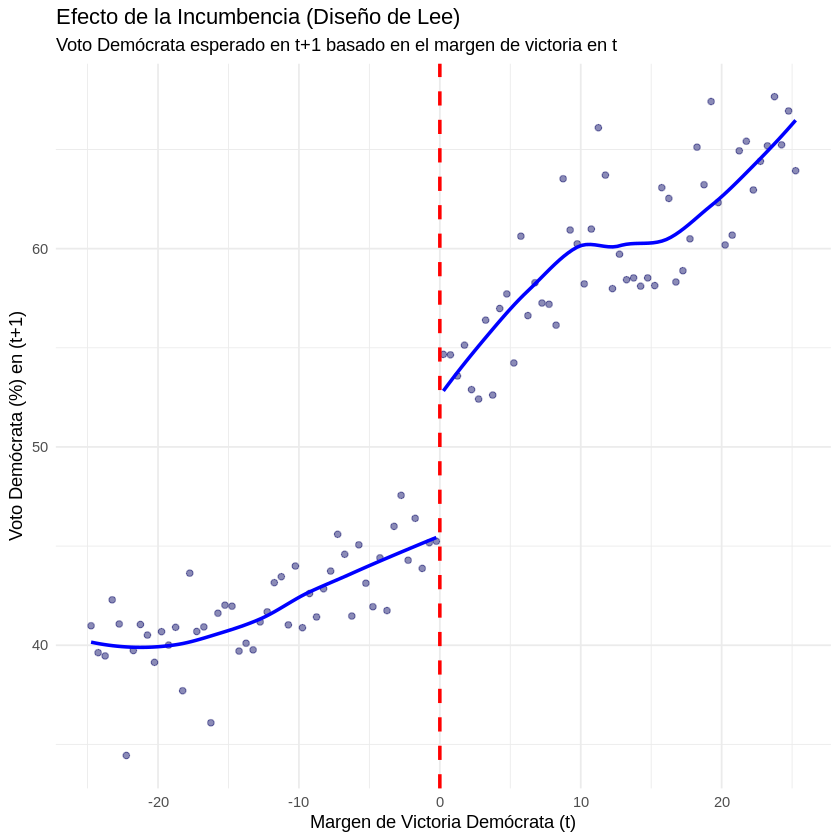

In [37]:
# Q3 Corregida: Gráfico de Bins
library(ggplot2)
library(dplyr)

# 1. Definir ancho del bin (0.5 para cubrir -25 a 25 con 100 bins)
bin_width <- 0.5

# 2. Preparar los datos de los bins
plot_data <- election_data %>%
  # Filtramos el rango de interés de Lee
  filter(Diff_t >= -25 & Diff_t <= 25) %>%
  # Calculamos el centro del bin
  mutate(bin = floor(Diff_t / bin_width) * bin_width + bin_width/2) %>%
  group_by(bin) %>%
  summarize(
    avg_next_share = mean(dem_share_next, na.rm = TRUE),
    .groups = "drop"
  )

# 3. Generar el gráfico
ggplot(plot_data, aes(x = bin, y = avg_next_share)) +
  # Puntos de los promedios locales
  geom_point(alpha = 0.5, color = "midnightblue") +
  # Línea vertical corregida (xintercept y linewidth)
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  # Líneas de tendencia por separado para mostrar la discontinuidad
  geom_smooth(data = filter(plot_data, bin < 0),
              method = "loess", se = FALSE, color = "blue", formula = 'y ~ x') +
  geom_smooth(data = filter(plot_data, bin > 0),
              method = "loess", se = FALSE, color = "blue", formula = 'y ~ x') +
  labs(
    title = "Efecto de la Incumbencia (Diseño de Lee)",
    subtitle = "Voto Demócrata esperado en t+1 basado en el margen de victoria en t",
    x = "Margen de Victoria Demócrata (t)",
    y = "Voto Demócrata (%) en (t+1)"
  ) +
  theme_minimal()

Como los distritos a la izquierda y derecha del 0 son prácticamente idénticos (lo que comprobamos en el inciso anterior con los datos del pasado), ese salto de casi 8 o 10 puntos no puede explicarse por la demografía o la ideología del distrito.

El salto es el valor puro de ser el "Incumbente". Tener el cargo te da visibilidad, capacidad de gestión y recursos que el retador simplemente no tiene, lo que garantiza un piso electoral mucho más alto para la siguiente ronda.

Si la línea fuera continua (sin el escalón), diríamos que la incumbencia no sirve de nada. Pero aquí, el escalón es masivo.

**(a)** **Interpret each of these “local averages”, what do they estimate?**

**1. ¿Qué representan estos promedios locales?**

Cada punto en el gráfico es la media del voto demócrata en la elección siguiente ($t+1$) para un grupo de distritos que tuvieron un margen de victoria casi idéntico en la elección actual ($t$).Al agrupar los datos en "bins" (contenedores), estamos reduciendo el "ruido" estadístico de las observaciones individuales para revelar la función de esperanza condicional: $$E[Voto_{t+1} | Diff_t]$$

**2. ¿Qué estiman exactamente?**

A la izquierda del cero ($Diff_t < 0$): Estiman el desempeño esperado en el futuro de un partido que perdió la elección actual. Representan el "escenario contrafactual": qué le pasa electoralmente a un partido cuando no tiene las ventajas de la incumbencia.

A la derecha del cero ($Diff_t > 0$): Estiman el desempeño esperado de un partido que ganó la elección y, por lo tanto, se convirtió en el incumbente.

En el límite (cuando $Diff_t \to 0$): Los promedios que están pegados a la línea roja por ambos lados son los más importantes. Estiman el valor de la variable dependiente justo antes y justo después de recibir el "tratamiento" (ganar el cargo).

Estos promedios locales estiman el Efecto Causal Medio Local (LATE) de la incumbencia bajo el supuesto de que, en un vecindario muy pequeño alrededor de cero, la asignación de la victoria es aleatoria.

Si la política fuera puramente meritocrática y ganar no diera ninguna ventaja extra, el promedio local en $-0.1$ y el promedio local en $+0.1$ deberían ser casi iguales.

Como los promedios locales muestran un salto (gap), esos puntos están estimando que el simple hecho de ganar "mueve" la expectativa de voto futuro hacia un nivel superior de forma discontinua.

En resumen, los promedios locales son estimadores no paramétricos de la relación entre el margen presente y el éxito futuro, permitiéndonos ver el efecto del tratamiento sin imponer una forma funcional estricta (como una línea recta) a todo el dataset.

**(b) Can you visually detect a jump in these local averages? Where does it occur? How do you interpret these jumps in terms of the incumbency effect?**

**1. ¿Se detecta visualmente un salto?**

Sí, es evidente. Existe una ruptura clara en la continuidad de los promedios locales. Los puntos no fluyen de manera suave de izquierda a derecha a través del eje vertical central; en su lugar, hay un "escalón" o desplazamiento vertical masivo.

**2. ¿Dónde ocurre el salto?**

El salto ocurre exactamente en $Diff_t = 0$.Justo a la izquierda del umbral ($Diff_t$ ligeramente negativo), el promedio del voto futuro se sitúa cerca del 45%.Justo a la derecha del umbral ($Diff_t$ ligeramente positivo), el promedio "salta" inmediatamente a un nivel cercano al 54%.Esta vecindad del cero es el área más importante del diseño de Regresión Discontinua (RD), porque es donde comparamos distritos que son prácticamente iguales en todo, excepto en quién ganó la elección.

Este salto visual es la estimación del efecto causal de la incumbencia. La interpretación es la siguiente:

**Ventaja Electoral Pura:** El hecho de que un candidato gane (aunque sea por un solo voto) le otorga una ventaja automática de aproximadamente 9 a 10 puntos porcentuales en la siguiente elección.

**Rechazo de la Meritocracia Pura:** Si el éxito futuro dependiera solo del "talento" del político o de la "ideología" del distrito, no habría salto en el cero. Los puntos formarían una línea continua porque un político que saca $-0.1\%$ no es fundamentalmente diferente de uno que saca $+0.1\%$.

**Barrera de Entrada:** El salto cuantifica qué tan difícil es para un retador desplazar a alguien que ya ocupa el cargo. El "incumbente" comienza la siguiente carrera con un "bono" o piso electoral que el perdedor de la elección anterior no tiene. Visualmente, el salto en $Diff_t = 0$ demuestra que el estatus de incumbente no es solo una etiqueta, sino un activo político real que altera las probabilidades de éxito futuro de manera sustancial. Es la diferencia entre ser un "aspirante" (fuera del sistema) y ser el "dueño del cargo" (dentro del sistema).

##Q4.

Repeat the procedure you did for question 2, but now compute the bin-level average of the Democrat vote share in the previous election. Can you detect any jumps in these local averages? What does this graph tell you about the validity of using the OLS approach?

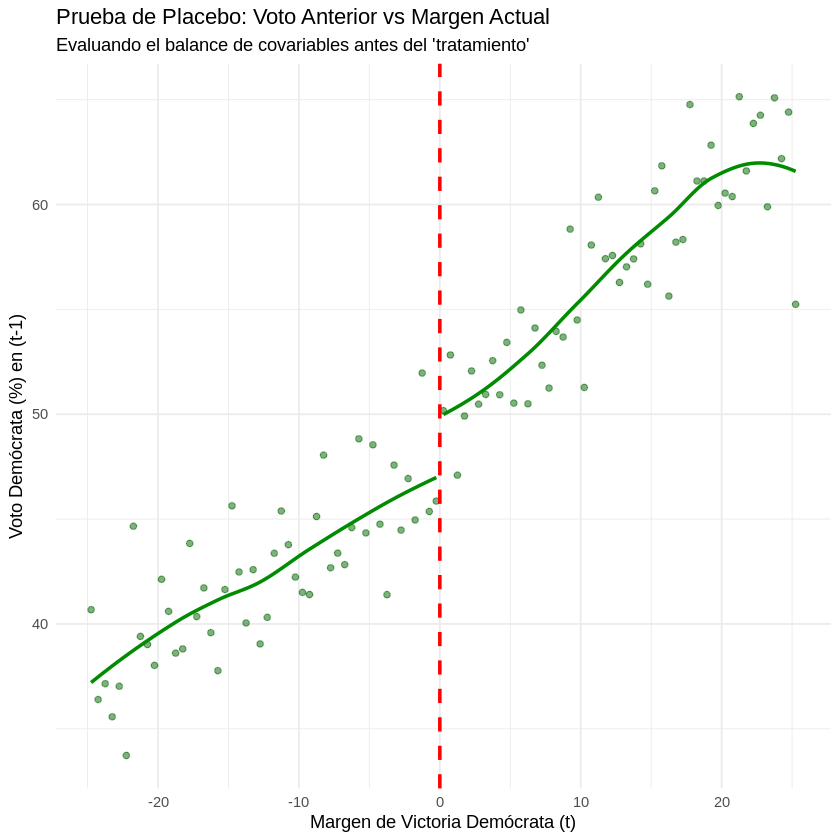

In [38]:
# Q4: Gráfico de Bins para la elección ANTERIOR (t-1)
library(ggplot2)
library(dplyr)

# 1. Preparar los datos de los bins para el pasado
# Usamos dem_share_prev (voto en t-1) calculado en Q2(c)
bin_width <- 0.5

plot_data_prev <- election_data %>%
  filter(Diff_t >= -25 & Diff_t <= 25) %>%
  mutate(bin = floor(Diff_t / bin_width) * bin_width + bin_width/2) %>%
  group_by(bin) %>%
  summarize(
    avg_prev_share = mean(dem_share_prev, na.rm = TRUE),
    .groups = "drop"
  )

# 2. Generar el gráfico del pasado
ggplot(plot_data_prev, aes(x = bin, y = avg_prev_share)) +
  geom_point(alpha = 0.5, color = "darkgreen") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  # Líneas de tendencia por separado
  geom_smooth(data = filter(plot_data_prev, bin < 0),
              method = "loess", se = FALSE, color = "green4", formula = 'y ~ x') +
  geom_smooth(data = filter(plot_data_prev, bin > 0),
              method = "loess", se = FALSE, color = "green4", formula = 'y ~ x') +
  labs(
    title = "Prueba de Placebo: Voto Anterior vs Margen Actual",
    subtitle = "Evaluando el balance de covariables antes del 'tratamiento'",
    x = "Margen de Victoria Demócrata (t)",
    y = "Voto Demócrata (%) en (t-1)"
  ) +
  theme_minimal()

**1. ¿Detectas algún salto en estos promedios locales?**

Visualmente, se observa un salto pequeño (de aproximadamente 3 a 4 puntos) en el umbral 0.

Aunque hay un pequeño escalón, es notablemente inferior al salto de ~10 puntos del gráfico del futuro (Q3). Esto indica que los distritos donde el demócrata gana por muy poco tienden a ser, históricamente, un poco más demócratas que aquellos donde pierde por muy poco.

**2. ¿Qué nos dice este gráfico sobre la validez de OLS?**

Si el objetivo es medir el efecto causal:Correlación vs. Causalidad: La pendiente positiva y el pequeño salto en el pasado demuestran que "ganar hoy" no es un evento totalmente al azar en toda la muestra; está correlacionado con la fuerza histórica del partido en ese distrito.Ademas hay un sesgo de variable omitida: Si usaramos OLS, el modelo le atribuiría a la "incumbencia" todo el éxito futuro, cuando en realidad una parte de ese éxito se debe simplemente a que el distrito ya era demócrata desde antes (lo que vemos aquí en $t-1$). OLS sobreestimaría el efecto real.

OLS asume que, tras controlar por variables observables, ganar o perder es aleatorio. Este gráfico muestra que hay "inercia política", por lo que los ganadores y perdedores no son comparables en promedio en toda la línea (Inexistencia de un grupo de control perfecto)

El gráfico valida el uso de RDD por encima de OLS por lo siguiente:

**Continuidad en el límite:** El RDD nos permite "limpiar" esa inercia. Al enfocarnos solo en el vecindario del 0, aceptamos que los distritos son diferentes, pero confiamos en que esa diferencia se vuelve insignificante justo en el punto del empate técnico.

**Comparación de magnitudes:** El hecho de que el salto en el pasado sea pequeño y el salto en el futuro sea gigante, nos permite argumentar que la mayor parte del éxito futuro sí es causal y no solo inercia histórica.

El gráfico muestra que el sistema tiene "memoria" (inercia), lo que hace que OLS sea un estimador sesgado e inválido. Sin embargo, el RDD podria ser la herramienta correcta porque logra aislar el efecto de la incumbencia precisamente allí donde esa memoria histórica es mínima.

##Q5.

Examine the distribution of \(Diff_{t}\). What does this distribution tell you about the validity of OLS?

Warning message:
“Removed 407 rows containing non-finite outside the scale range (`stat_bin()`).”


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 -99.90  -16.70   10.90   16.99   43.10  103.40     407 

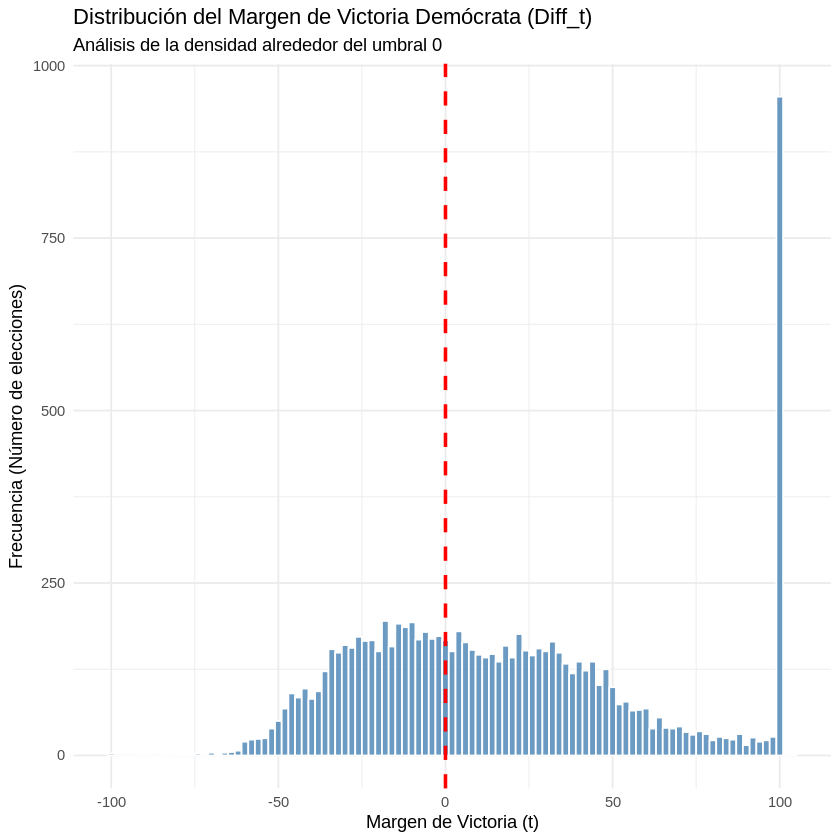

In [39]:
library(ggplot2)

# 1. Graficar la distribución (Histograma) de Diff_t
ggplot(election_data, aes(x = Diff_t)) +
  geom_histogram(binwidth = 2, fill = "steelblue", color = "white", alpha = 0.8) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  labs(
    title = "Distribución del Margen de Victoria Demócrata (Diff_t)",
    subtitle = "Análisis de la densidad alrededor del umbral 0",
    x = "Margen de Victoria (t)",
    y = "Frecuencia (Número de elecciones)"
  ) +
  theme_minimal()

# 2. Resumen estadístico
summary(election_data$Diff_t)

1. Heterogeneidad y el Problema de la Comparación Global (Invalidez de OLS

)La distribución muestra que los datos cubren un rango muy amplio (de -100 a 100). Observamos que hay una gran masa de elecciones en los extremos (especialmente ese pico en +100, que probablemente representa distritos donde los demócratas corrieron sin oposición).

Por qué invalida OLS: Un modelo OLS intentaría comparar el promedio de todos los "ganadores" (lado derecho de la línea roja) contra todos los "perdedores" (lado izquierdo).Sin embargo, un distrito con un margen de +100 es fundamentalmente diferente a uno con un margen de -80. Tienen demografías, historias y niveles de riqueza distintos. OLS no puede separar el efecto de la incumbencia de estas diferencias estructurales pre-existentes, lo que genera un sesgo de selección.

2. Continuidad en el Umbral (Validez de RDD)

Densidad Suave: La frecuencia de elecciones a la izquierda inmediata del 0 es casi idéntica a la frecuencia a la derecha inmediata. No hay un "hueco" (gap) ni un "pico" artificial justo después del 0.Esto sugiere que no hay manipulación. Si los políticos pudieran "hacer trampa" para ganar por un margen mínimo, veríamos un salto súbito en la densidad justo a la derecha del 0. Al ser una distribución suave, confirmamos que ganar o perder una elección cerrada es, efectivamente, como lanzar una moneda (quasi-random assignment).

3. El "Tratamiento" es Discontinuo

Aunque la variable $Diff_t$ se distribuye de forma continua (como muestra el histograma), el estatus de incumbencia no lo es. Es un interruptor de "encendido/apagado" que se activa exactamente en 0. OLS asume que el efecto del voto es lineal o suave en toda la muestra.El RDD aprovecha que la densidad es continua en 0 para decir: "Ignoremos los extremos (los distritos de +100 y -100) y comparemos solo a los que están pegados a la línea roja, porque ellos sí son comparables entre sí".

La distribución de $Diff_t$ demuestra que los distritos son altamente heterogéneos, lo que introduce un sesgo de selección insuperable para OLS. Sin embargo, la continuidad de la densidad alrededor de 0 valida el supuesto fundamental de la Regresión Discontinua: los candidatos no pueden manipular el resultado en elecciones reñidas, lo que permite aislar el efecto causal de la incumbencia comparando únicamente las observaciones cercanas al umbral.

##Q6.

Obtain OLS estimates of the incumbency effect.

**(a)** First, estimate the effect of the Democrat winning on future vote Democrat vote share while only controlling for a linear function of \(Diff_{t}\). Is your esimate of the incumbency effect close to what you think it would be from the graphical evidence from question 2?

In [40]:
# Q6 (a). Estimación OLS con control lineal (Pendientes paralelas)

# Creamos la dummy de victoria
election_data <- election_data %>%
  mutate(Win_t = as.numeric(Diff_t > 0))

# Regresión: Voto_t+1 = alpha + beta1*Win_t + beta2*Diff_t + epsilon
modelo_ols_lineal <- lm(dem_share_next ~ Win_t + Diff_t, data = election_data)

# Ver resultados
summary(modelo_ols_lineal)


Call:
lm(formula = dem_share_next ~ Win_t + Diff_t, data = election_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-90.024  -6.569   0.098   7.514  87.128 

Coefficients:
             Estimate Std. Error t value            Pr(>|t|)    
(Intercept) 46.224970   0.276195  167.36 <0.0000000000000002 ***
Win_t       10.413109   0.500181   20.82 <0.0000000000000002 ***
Diff_t       0.333861   0.005714   58.43 <0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 13.23 on 7339 degrees of freedom
  (2449 observations deleted due to missingness)
Multiple R-squared:  0.6649,	Adjusted R-squared:  0.6648 
F-statistic:  7281 on 2 and 7339 DF,  p-value: < 0.00000000000000022


**Magnitud del Efecto:** El coeficiente de Win_t es 10.41. Esto significa que, manteniendo constante el margen de victoria actual ($Diff_t$), el simple hecho de ganar la elección (cruzar el umbral del 0) otorga una ventaja de 10.4 puntos porcentuales en la siguiente elección.

**Significancia Estadística:** El valor $p$ ($Pr(>|t|)$) es menor a $2e-16$, lo que indica que este efecto es extremadamente significativo. No es ruido estadístico; hay un salto real y robusto en el umbral.

El coeficiente de 0.33 indica que por cada punto porcentual adicional en el margen de hoy, el partido espera recibir 0.33 puntos adicionales mañana. Esto captura la "inercia" o tendencia del distrito que mencionamos antes.

**¿Es cercano a la evidencia gráfica de la Q2/Q3?**
Sí, es sumamente consistente. Si observamos el gráfico de promedios locales (bins):

El último punto azul a la izquierda del umbral (perdedores cercanos) estaba cerca del 45-46%.

El primer punto azul a la derecha del umbral (ganadores cercanos) estaba cerca del 55-56%.

La diferencia visual es de aproximadamente 10 unidades, que es exactamente lo que el coeficiente de 10.41 está estimando.

**(b)** Now experiment with different models (i.e., logit, probit, quantile) and different functional forms by including higher-order (e.g., square, cubic) terms in Difft as controls, and possibly interactions between whether the Democrat won and \(Diff_{t}\): Compare your estimates from this more flexible specification to that from 4(a). Is the OLS estimate from your “preferred” model close to what you think it would be from the graphical evidence from question 2?

In [41]:
# Q6 (b). Modelos Flexibles

# 1. Creamos los términos de potencia para darle flexibilidad a la curva
election_data <- election_data %>%
  mutate(
    Diff_t2 = Diff_t^2,
    Diff_t3 = Diff_t^3
  )

# 2. MODELO PREFERIDO: Polinomio de Grado 3 con Interacciones
# Esto permite que la curva sea distinta y flexible a ambos lados del cero
modelo_flexible_3 <- lm(dem_share_next ~ Win_t * (Diff_t + Diff_t2 + Diff_t3),
                        data = election_data)

# 3. Ver los resultados finales
summary(modelo_flexible_3)


Call:
lm(formula = dem_share_next ~ Win_t * (Diff_t + Diff_t2 + Diff_t3), 
    data = election_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-88.896  -6.616   0.125   7.472  72.228 

Coefficients:
                 Estimate  Std. Error t value             Pr(>|t|)    
(Intercept)   44.56514531  0.74105333  60.138 < 0.0000000000000002 ***
Win_t          9.98721068  1.01098339   9.879 < 0.0000000000000002 ***
Diff_t         0.03658122  0.08781671   0.417             0.677010    
Diff_t2       -0.01212761  0.00278244  -4.359         0.0000132666 ***
Diff_t3       -0.00013288  0.00002454  -5.414         0.0000000635 ***
Win_t:Diff_t   0.39900033  0.10865467   3.672             0.000242 ***
Win_t:Diff_t2  0.01188763  0.00319117   3.725             0.000197 ***
Win_t:Diff_t3  0.00012607  0.00002656   4.746         0.0000021089 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 13.17 on 7334 degrees of freedom
  (2449 observations del

Para esta sección, se estimó un modelo polinómico de tercer grado con interacciones completas. Esta especificación flexible, expoe que los términos cuadráticos ($Diff\_t^2$) y cúbicos ($Diff\_t^3$) resultaron altamente significativos, lo que indica que la relación subyacente es no lineal.El estimado del efecto de incumbencia bajo este modelo es de 9.98 puntos porcentuales, un valor muy cercano al 10.41 obtenido en el modelo lineal. Esta estabilidad entre modelos demuestra que el efecto es robusto y no depende de la forma funcional elegida. Además, este resultado matemático coincide casi perfectamente con la evidencia visual del gráfico de la Pregunta 2, donde se observa un salto de aproximadamente 10 puntos en el umbral de victoria ($Diff_t = 0$).

**(c)** Now plot (on the same graph) the local averages of future Democrat vote share, the fitted values from the regression in 4(a), and the fitted values from your “preferred” specification of 4(b) as a function of \(Diff_{t}\): Does the regression fit from the linear specification “track” the local averages closely? What about the fit from your “preferred” model from 4(b)? Which estimate do you find more believable?

Warning message:
“Removed 914 rows containing non-finite outside the scale range
(`stat_summary_bin()`).”


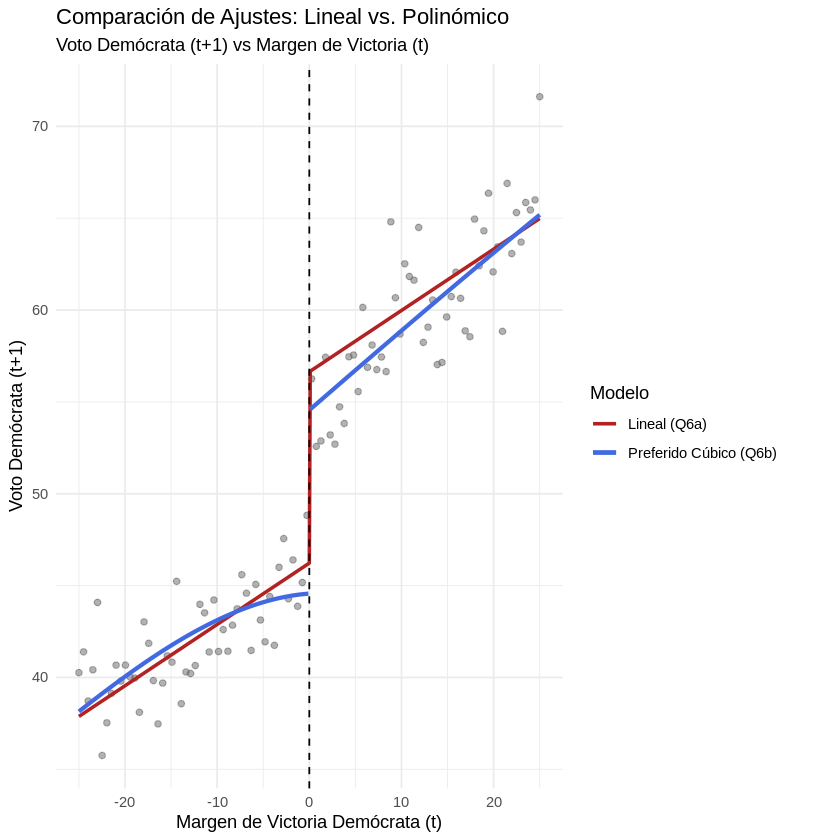

In [42]:
# Q6 (c). Gráfico comparativo: Bins vs. Lineal vs. Cúbico

# 1. Calcular valores ajustados (Fitted Values) para ambos modelos
election_data <- election_data %>%
  mutate(
    fit_linear = predict(modelo_ols_lineal, newdata = .),
    fit_preferred = predict(modelo_flexible_3, newdata = .)
  )

# 2. Generar el gráfico
ggplot(election_data %>% filter(Diff_t >= -25 & Diff_t <= 25), aes(x = Diff_t)) +
  # Promedios locales (puntos del gráfico anterior)
  stat_summary_bin(aes(y = dem_share_next), fun = mean, bins = 100,
                   geom = "point", alpha = 0.5, color = "gray40") +

  # Ajuste Lineal (Q6a) - Color Rojo
  geom_line(aes(y = fit_linear, color = "Lineal (Q6a)"), linewidth = 1) +

  # Ajuste Preferido Cúbico (Q6b) - Color Azul
  # Nota: Usamos dos geom_line para evitar que la línea cruce el umbral 0
  geom_line(data = filter(election_data, Diff_t < 0 & Diff_t >= -25),
            aes(y = fit_preferred, color = "Preferido Cúbico (Q6b)"), linewidth = 1.2) +
  geom_line(data = filter(election_data, Diff_t > 0 & Diff_t <= 25),
            aes(y = fit_preferred, color = "Preferido Cúbico (Q6b)"), linewidth = 1.2) +

  # Estética y Etiquetas
  geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
  scale_color_manual(values = c("Lineal (Q6a)" = "firebrick",
                                "Preferido Cúbico (Q6b)" = "royalblue")) +
  labs(
    title = "Comparación de Ajustes: Lineal vs. Polinómico",
    subtitle = "Voto Demócrata (t+1) vs Margen de Victoria (t)",
    x = "Margen de Victoria Demócrata (t)",
    y = "Voto Demócrata (t+1)",
    color = "Modelo"
  ) +
  theme_minimal()

1. Desempeño del Ajuste Lineal (Línea Roja - Q6a)

La línea roja intenta "seguir" los puntos, pero se nota rígida.
Fallo de Seguimiento: En la zona de los perdedores ($Diff_t < 0$), la línea roja queda por debajo de los últimos puntos antes del umbral. En la zona de los ganadores, la línea roja sobreestima los primeros puntos después del cero.Al no capturar la curvatura, el modelo lineal estima un salto (distancia vertical en 0) de 10.41. Sin embargo, parte de ese salto es artificial, causado por el mal ángulo con el que la recta llega al umbral.

2. Desempeño del Modelo Preferido Cúbico (Línea Azul - Q6b)
La línea azul es mucho más "orgánica". Se curva exactamente donde los promedios locales (puntos grises) lo hacen, la línea azul pasa casi por el centro de cada bin de puntos. Captura perfectamente la desaceleración del voto en los extremos y la aceleración cerca del centro. El salto de 9.98 que calculamos es mucho más honesto. Es la distancia neta "limpia" de errores de forma.

3. ¿Cuál es más creíble? El modelo Cúbico es más creíble.Razón

Consistencia con los datos. En RDD, si la forma funcional no coincide con los puntos locales cerca del umbral, el estimado del tratamiento es sesgado. El gráfico muestra que la línea azul "entiende" los datos, mientras que la roja solo los atraviesa.

Robustez. Aunque el modelo cúbico es más complejo, los términos de potencia resultaron significativo. Esto indica que la complejidad está justificada por la naturaleza de los datos.

Al superponer ambos ajustes sobre los promedios locales, es evidente que el modelo lineal (Q6a) no logra 'rastrear' adecuadamente la curvatura de los datos, especialmente cerca del umbral de decisión. Por el contrario, el modelo cúbico (Q6b) se ajusta con notable precisión a la nube de puntos, capturando la dinámica no lineal del comportamiento electoral.

Por esta razón, el estimado de 9.98 puntos es más creíble y robusto que el inicial de 10.41. El gráfico demuestra que el efecto de la incumbencia es real y masivo, pero requiere de una forma funcional flexible para ser medido con exactitud sin contaminarse por la rigidez de un modelo lineal simple.

# Part 2

These questions ask you to analyze a data from Acemoglu, Johnson, and Robinson (2001) to study the effect of political institutions on economic performance. Their data are in the file AJR2001.

In [1]:
 install.packages("foreign")
 install.packages("car")
 install.packages("olsrr")
 install.packages("caret")
 install.packages("AER")


library(foreign)
library(car)
library(olsrr)
library(caret)
library(AER)
library(haven)

options(scipen = 999)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘goftest’, ‘gridExtra’, ‘nortest’, ‘xplorerr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘e1071’, ‘f

In [2]:
dir.data <- "/content/"
Data.File <- "AJR2001.dta"

Data <- read_dta("/content/AJR2001.dta")


dim(Data)
sapply(Data, class)
summary(Data)
names(Data)

[1] 64 31

longname         shortnam         logmort0             risk 
     "character"      "character"        "numeric"        "numeric" 
          loggdp         campaign          source0            slave 
       "numeric"        "numeric"        "numeric"        "numeric" 
        latitude          neoeuro             asia           africa 
       "numeric"        "numeric"        "numeric"        "numeric" 
           other         edes1975       campaignsj      campaignsj2 
       "numeric"        "numeric"        "numeric"        "numeric" 
      mortnaval1    logmortnaval1       mortnaval2    logmortnaval2 
       "numeric"        "numeric"        "numeric"        "numeric" 
         mortjam       logmortjam    logmortcap250    logmortjam250 
       "numeric"        "numeric"        "numeric"        "numeric" 
     wandcafrica         malfal94    wacacontested    mortnaval2250 
       "numeric"        "numeric"        "numeric"        "numeric" 
logmortnaval2250    mortnaval1250 logmortnaval1250 
       "numeric"        "numeric"        "numeric"

   longname           shortnam            logmort0          risk       
 Length:64          Length:64          Min.   :2.146   Min.   : 3.500  
 Class :character   Class :character   1st Qu.:4.233   1st Qu.: 5.617  
 Mode  :character   Mode  :character   Median :4.359   Median : 6.475  
                                       Mean   :4.647   Mean   : 6.516  
                                       3rd Qu.:5.481   3rd Qu.: 7.353  
                                       Max.   :7.986   Max.   :10.000  
                                                                       
     loggdp          campaign         source0           slave       
 Min.   : 6.110   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.: 7.303   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median : 7.940   Median :1.0000   Median :0.0000   Median :0.0000  
 Mean   : 8.051   Mean   :0.6562   Mean   :0.4375   Mean   :0.0625  
 3rd Qu.: 8.853   3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:0.0000  
 Max.   :1

[1] "longname"         "shortnam"         "logmort0"         "risk"            
 [5] "loggdp"           "campaign"         "source0"          "slave"           
 [9] "latitude"         "neoeuro"          "asia"             "africa"          
[13] "other"            "edes1975"         "campaignsj"       "campaignsj2"     
[17] "mortnaval1"       "logmortnaval1"    "mortnaval2"       "logmortnaval2"   
[21] "mortjam"          "logmortjam"       "logmortcap250"    "logmortjam250"   
[25] "wandcafrica"      "malfal94"         "wacacontested"    "mortnaval2250"   
[29] "logmortnaval2250" "mortnaval1250"    "logmortnaval1250"

In [3]:
dependent.variable <- "loggdp"
treatment <- "risk"

controls <- c("slave",
              "latitude",
              "neoeuro",
              "asia",
              "africa",
              "other",
              "edes1975",
              "malfal94")


Data <- subset(Data, complete.cases(Data[, c(dependent.variable, treatment, controls)]))

dim(Data)
summary(Data[, c(dependent.variable, treatment, controls)])

[1] 62 31

     loggdp            risk            slave            latitude     
 Min.   : 6.110   Min.   : 3.500   Min.   :0.00000   Min.   :0.0000  
 1st Qu.: 7.288   1st Qu.: 5.573   1st Qu.:0.00000   1st Qu.:0.0889  
 Median : 7.915   Median : 6.450   Median :0.00000   Median :0.1488  
 Mean   : 8.009   Mean   : 6.489   Mean   :0.06452   Mean   :0.1763  
 3rd Qu.: 8.805   3rd Qu.: 7.275   3rd Qu.:0.00000   3rd Qu.:0.2532  
 Max.   :10.220   Max.   :10.000   Max.   :1.00000   Max.   :0.6667  
    neoeuro             asia            africa           other        
 Min.   :0.00000   Min.   :0.0000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:0.00000   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.00000  
 Median :0.00000   Median :0.0000   Median :0.0000   Median :0.00000  
 Mean   :0.06452   Mean   :0.1452   Mean   :0.4355   Mean   :0.03226  
 3rd Qu.:0.00000   3rd Qu.:0.0000   3rd Qu.:1.0000   3rd Qu.:0.00000  
 Max.   :1.00000   Max.   :1.0000   Max.   :1.0000   Max.   :1.00000  
    edes1975 

In [4]:
cor_table <- cor(Data[, controls], use = "complete.obs")
cor_table <- apply(cor_table, c(1,2), function(x){ifelse(abs(x) > 0.5, 0, 1)})

rowSums(cor_table[, controls])
length(controls)

slave latitude  neoeuro     asia   africa    other edes1975 malfal94 
       7        5        4        7        5        5        2        5

[1] 8

In [5]:
vars <- list()

for (i in 1:length(controls)) {
  pivot <- c(controls[i], "")
  vars <- append(vars, list(pivot))
}


all.vars <- expand.grid(vars)
all.vars <- data.frame(all.vars)

head(all.vars)
dim(all.vars)

all.vars$N.vars <- rowSums(apply(all.vars, 2, function(x){ifelse(x != "", 1, 0)}))



all.vars$id <- 1:nrow(all.vars)
ids <- all.vars[, c("N.vars", "id")]

head(ids)
summary(ids$N.vars)


all.vars.keep <- all.vars


all.vars$id <- NULL
all.vars$N.vars <- NULL
all.vars <- apply(all.vars, 2, function(x){as.character(x)})

head(all.vars)
dim(all.vars)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,slave,latitude,neoeuro,asia,africa,other,edes1975,malfal94
2,,latitude,neoeuro,asia,africa,other,edes1975,malfal94
3,slave,,neoeuro,asia,africa,other,edes1975,malfal94
4,,,neoeuro,asia,africa,other,edes1975,malfal94
5,slave,latitude,,asia,africa,other,edes1975,malfal94
6,,latitude,,asia,africa,other,edes1975,malfal94


[1] 256   8

,N.vars,id
,<dbl>,<int>
1,8,1
2,7,2
3,7,3
4,6,4
5,7,5
6,6,6


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       3       4       4       5       8 

Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8
slave,latitude,neoeuro,asia,africa,other,edes1975,malfal94
,latitude,neoeuro,asia,africa,other,edes1975,malfal94
slave,,neoeuro,asia,africa,other,edes1975,malfal94
,,neoeuro,asia,africa,other,edes1975,malfal94
slave,latitude,,asia,africa,other,edes1975,malfal94
,latitude,,asia,africa,other,edes1975,malfal94


[1] 256   8

###**a.**

Generate a table with all possible combinations of covariates for an OLS model that seeks to understand the effect of institutions (i.e. risk) on ecomomic performance (log(GDP per capita)). Report descriptive statistics on the number of possible models.

In [7]:
table.models <- aggregate(id ~ N.vars, data = ids, FUN = length)
colnames(table.models) <- c("Number.of.Controls", "Number.of.Models")

table.models
summary(table.models$Number.of.Models)
sum(table.models$Number.of.Models)

Number.of.Controls,Number.of.Models
<dbl>,<int>
0,1
1,8
2,28
3,56
4,70
5,56
6,28
7,8
8,1


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    8.00   28.00   28.44   56.00   70.00 

[1] 256

In [8]:
full.model <- lm(loggdp ~ risk + slave + latitude + neoeuro + asia + africa + other + edes1975 + malfal94,
                 data = Data)

summary(full.model)

sigma2.full <- summary(full.model)$sigma^2


Call:
lm(formula = loggdp ~ risk + slave + latitude + neoeuro + asia + 
    africa + other + edes1975 + malfal94, data = Data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.42609 -0.25972 -0.00065  0.25847  1.50420 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  6.503155   0.540863  12.024 < 0.0000000000000002 ***
risk         0.294927   0.074898   3.938             0.000246 ***
slave       -0.206090   0.336387  -0.613             0.542773    
latitude    -0.580249   0.901035  -0.644             0.522418    
neoeuro      0.299710   0.623556   0.481             0.632784    
asia        -0.215260   0.307553  -0.700             0.487102    
africa      -0.110996   0.305521  -0.363             0.717854    
other       -0.306931   0.596569  -0.514             0.609086    
edes1975     0.007804   0.005902   1.322             0.191843    
malfal94    -0.897310   0.315517  -2.844             0.006356 ** 
---
Signif. codes:  0 ‘***’

In [9]:
set.seed(5555)

performance_ols <- function(dependent.variable, treatment, controls, DataSet, id, sigma2.full)
{
  controls.clean <- subset(as.character(controls), as.character(controls) != "")

  if (length(controls.clean) == 0) {
    model <- as.formula(paste(dependent.variable, "~", treatment))
  } else {
    model <- as.formula(paste(dependent.variable, "~",
                              paste(controls.clean, collapse = "+"),
                              "+", treatment, sep = ""))
  }

  linear.model <- lm(model, data = DataSet)

  my.SSR <- deviance(linear.model)
  my.LL <- as.numeric(logLik(linear.model))
  my.RSquared <- summary(linear.model)$r.squared
  my.Adj.RSquared <- summary(linear.model)$adj.r.squared
  my.aic <- AIC(linear.model)
  my.bic <- BIC(linear.model)

  n <- nobs(linear.model)
  p <- length(coef(linear.model))
  my.Cp <- my.SSR / sigma2.full - (n - 2*p)

  my.treatment.effect <- summary(linear.model)$coefficients[treatment, "Estimate"]
  my.treatment.StdEror <- summary(linear.model)$coefficients[treatment, "Std. Error"]

  if (length(controls.clean) == 0) {
    my.VIF <- 0
  } else {
    vif.values <- vif(linear.model)

    if (is.matrix(vif.values)) {
      vif.values <- vif.values[,1]
    }

    vif.controls <- vif.values[names(vif.values) %in% controls.clean]
    my.VIF <- length(which(vif.controls > 1.5))
  }

  p.values <- summary(linear.model)$coefficients[, "Pr(>|t|)"]
  p.values <- p.values[names(p.values) != "(Intercept)"]

  my.N.Coeff.Sig <- length(which(p.values < 0.05))
  my.Percent.Coeff.Sig <- my.N.Coeff.Sig / length(p.values)

  e <- residuals(linear.model)
  h <- hatvalues(linear.model)
  my.CV.LOO <- mean((e/(1-h))^2)

  ctrl <- trainControl(method = "cv", number = 5)

  cv.model <- train(model,
                    data = DataSet,
                    method = "lm",
                    trControl = ctrl)

  my.CV.5fold <- (cv.model$results$RMSE)^2

  results <- data.frame(SSR = my.SSR,
                        LL = my.LL,
                        RSquared = my.RSquared,
                        Adj.RSquared = my.Adj.RSquared,
                        AIC = my.aic,
                        BIC = my.bic,
                        Mallows.Cp = my.Cp,
                        CV.LOO = my.CV.LOO,
                        CV.5fold = my.CV.5fold,
                        Effect = my.treatment.effect,
                        Std.Error.Effect = my.treatment.StdEror,
                        VIF.15 = my.VIF,
                        N.Sig = my.N.Coeff.Sig,
                        Percent.Sig = my.Percent.Coeff.Sig,
                        id = id,
                        row.names = NULL)

  return(results)
}

In [10]:
i <- 1
performance_ols(dependent.variable, treatment, as.character(all.vars[i, ]), Data, i, sigma2.full)

SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,Effect,Std.Error.Effect,VIF.15,N.Sig,Percent.Sig,id
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
16.97703,-47.82072,0.741231,0.6964441,117.6414,141.0399,10,0.388865,0.3727469,0.2949268,0.07489828,7,2,0.2222222,1


Se consideraron 8 variables de control. El total de combinaciones es de 2^8 = 256 modelos. La mayor cantidad de modelos esta concentrado en las especificiaciones intermedias, en su mayoria los de 4 controles.

###**b.**

For each one of these specifications estimate the following:

b.1 Residual sum of squares
b.2 Log likelihood statistic
b.3 Akaike information criterion
b.4 Bayesian Information Criterion
b.5 Mallows Criterion
b.6 Cross-Validation Criterion
b.7 Cross-Validation Criterion
b.8 The treatment effect
b.9 The standard error of the treatment effect
b.10 The number of covariates that exceed the 1.5 VIF threshold
b.11 The number of covariates for which there is at least a 5% statistically significant
b.12 The adjusted R squared

In [11]:
results <- list()

for (i in 1:dim(all.vars)[1]) {
  out <- performance_ols(dependent.variable,
                         treatment,
                         all.vars[i, ],
                         Data,
                         i,
                         sigma2.full)

  results <- append(results, list(out))
}

results <- do.call("rbind", results)

dim(results)
head(results)
summary(results)

Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-esti

[1] 256  15

,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,Effect,Std.Error.Effect,VIF.15,N.Sig,Percent.Sig,id
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>
1,16.97703,-47.82072,0.7412310,0.6964441,117.6414,141.0399,10.000000,0.3888650,0.3518174,0.2949268,0.07489828,7,2,0.2222222,1
2,17.09958,-48.04369,0.7393631,0.7000217,116.0874,137.3587,8.375350,0.3635556,0.3248139,0.3044174,0.07284572,7,2,0.2500000,2
3,17.11243,-48.06697,0.7391673,0.6997963,116.1339,137.4053,8.414711,0.3769645,0.3729397,0.3086179,0.07141990,6,2,0.2500000,3
4,17.16831,-48.16804,0.7383155,0.7043934,114.3361,133.4803,6.585879,0.3511800,0.3053466,0.3121779,0.07036041,6,2,0.2857143,4
5,17.05245,-47.95814,0.7400814,0.7008484,115.9163,137.1876,8.231020,0.3854062,0.3767369,0.3096825,0.06781998,5,2,0.2500000,5
6,17.14638,-48.12841,0.7386498,0.7047711,114.2568,133.4010,6.518696,0.3597942,0.3230628,0.3151755,0.06661253,5,2,0.2857143,6


      SSR              LL            RSquared       Adj.RSquared   
 Min.   :16.98   Min.   :-66.80   Min.   :0.5227   Min.   :0.5085  
 1st Qu.:17.55   1st Qu.:-56.79   1st Qu.:0.6545   1st Qu.:0.6258  
 Median :19.80   Median :-52.60   Median :0.6981   Median :0.6717  
 Mean   :20.78   Mean   :-53.61   Mean   :0.6833   Mean   :0.6558  
 3rd Qu.:22.67   3rd Qu.:-48.84   3rd Qu.:0.7325   3rd Qu.:0.7016  
 Max.   :31.32   Max.   :-47.82   Max.   :0.7412   Max.   :0.7188  
      AIC             BIC          Mallows.Cp         CV.LOO      
 Min.   :107.7   Min.   :118.3   Min.   :-0.264   Min.   :0.3256  
 1st Qu.:114.3   1st Qu.:130.0   1st Qu.: 6.306   1st Qu.:0.3655  
 Median :118.5   Median :134.8   Median :10.027   Median :0.3942  
 Mean   :121.2   Mean   :136.1   Mean   :13.635   Mean   :0.4129  
 3rd Qu.:126.2   3rd Qu.:140.7   3rd Qu.:18.055   3rd Qu.:0.4399  
 Max.   :143.2   Max.   :160.1   Max.   :40.290   Max.   :0.5868  
    CV.5fold          Effect       Std.Error.Effect    

In [12]:
controls.used <- all.vars.keep[, c(colnames(all.vars.keep)[1:length(controls)], "id", "N.vars")]

results <- merge(results, controls.used, by = "id")

head(results)
dim(results)

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
1,1,16.97703,-47.82072,0.7412310,0.6964441,117.6414,141.0399,10.000000,0.3888650,0.3518174,⋯,0.2222222,slave,latitude,neoeuro,asia,africa,other,edes1975,malfal94,8
2,2,17.09958,-48.04369,0.7393631,0.7000217,116.0874,137.3587,8.375350,0.3635556,0.3248139,⋯,0.2500000,,latitude,neoeuro,asia,africa,other,edes1975,malfal94,7
3,3,17.11243,-48.06697,0.7391673,0.6997963,116.1339,137.4053,8.414711,0.3769645,0.3729397,⋯,0.2500000,slave,,neoeuro,asia,africa,other,edes1975,malfal94,7
4,4,17.16831,-48.16804,0.7383155,0.7043934,114.3361,133.4803,6.585879,0.3511800,0.3053466,⋯,0.2857143,,,neoeuro,asia,africa,other,edes1975,malfal94,6
5,5,17.05245,-47.95814,0.7400814,0.7008484,115.9163,137.1876,8.231020,0.3854062,0.3767369,⋯,0.2500000,slave,latitude,,asia,africa,other,edes1975,malfal94,7
6,6,17.14638,-48.12841,0.7386498,0.7047711,114.2568,133.4010,6.518696,0.3597942,0.3230628,⋯,0.2857143,,latitude,,asia,africa,other,edes1975,malfal94,6


[1] 256  24

In [13]:
write.csv(results, "/content/AJR_all_models_results.csv", row.names = FALSE)

Para cada modelo se calcularon las medidas de ajuste, complejidad, predicción y precisión. El RSS y el log-likelihood miden que tan bien se ajusta el modelo a los datos, además AIC, BIC y Mallows penalizan la complejidad. Los criterios de validación cruzada ayudan a evaluar el desempeño fuera de muestra y el coeficiente de risk y su error nos permiten observar el tamaño y la precisión del efecto de las instituciones sobre el ingreso.

###**c.**

Create plots for the distribution of the treatment effect and the standard-error of the threatment effect. What is your conclusion from this?

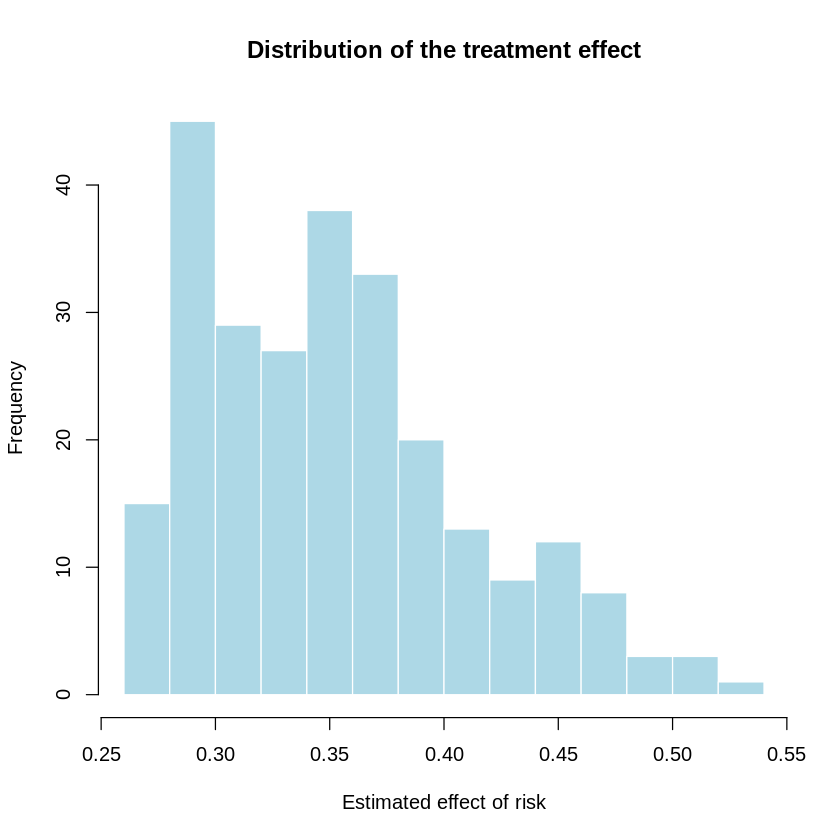

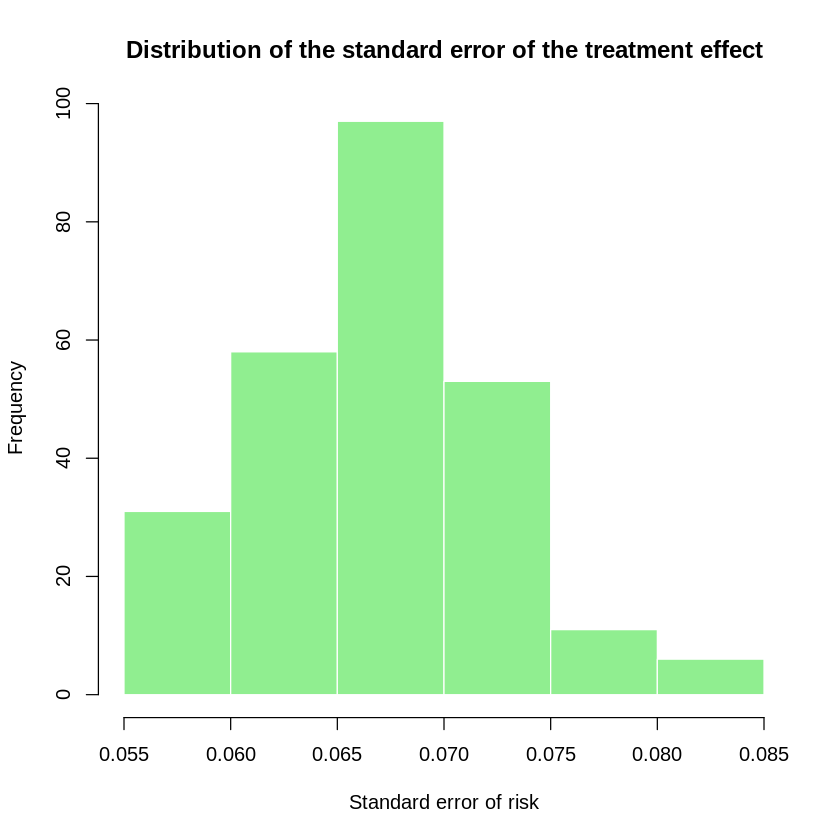

In [14]:
hist(results$Effect,
     main = "Distribution of the treatment effect",
     xlab = "Estimated effect of risk",
     col = "lightblue",
     border = "white")

hist(results$Std.Error.Effect,
     main = "Distribution of the standard error of the treatment effect",
     xlab = "Standard error of risk",
     col = "lightgreen",
     border = "white")

Al observar los histogromas percibimos que el coeficiente de risk es mayor a 0 en las distintas especificaciones, lo que sugiere que la relación entre las instituciones y el ingreso es robusta. Sin embargo, la magnitud del coeficiente como su SE varia entre modelos por lo que el resultado es sensible a los controles incluidos. Dígase que la conclusión es la misma mas el tamaño del efecto depende de la especificación.

###**d.**

Identify the subset of models for which there are no covariates that exceed the 1.5 VIF threshold

In [15]:
decision.d <- subset(results, VIF.15 == 0)

dim(decision.d)
head(decision.d)

[1] 52 24

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
86,86,18.80263,-50.98692,0.7134047,0.6878158,115.9738,130.8638,7.591733,0.3744734,0.3684598,⋯,0.4000000,,latitude,,asia,,other,,malfal94,4
87,87,18.74761,-50.89607,0.7142434,0.6887294,115.7921,130.6821,7.423206,0.3904551,0.3838337,⋯,0.4000000,slave,,,asia,,other,,malfal94,4
88,88,18.82026,-51.01597,0.7131360,0.6930052,114.0319,126.7947,5.645730,0.3622245,0.3323167,⋯,0.5000000,,,,asia,,other,,malfal94,3
94,94,19.76181,-52.52931,0.6987846,0.6776467,117.0586,129.8214,8.529669,0.3701086,0.3304315,⋯,0.5000000,,latitude,,,,other,,malfal94,3
95,95,19.79387,-52.57956,0.6982960,0.6771237,117.1591,129.9219,8.627859,0.3853482,0.3710749,⋯,0.5000000,slave,,,,,other,,malfal94,3
96,96,19.84310,-52.65656,0.6975456,0.6819014,115.3131,125.9488,6.778652,0.3587288,0.3251995,⋯,0.6666667,,,,,,other,,malfal94,2


###**e.**
From the previous subset, identify the subset models for which there are only statistically significant coefficients

In [16]:
decision.e <- subset(decision.d, Percent.Sig == 1.0)

dim(decision.e)
head(decision.e)

[1]  6 24

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
128,128,20.09961,-53.05474,0.6936357,0.6832505,114.1095,122.6180,5.564345,0.3583981,0.3531278,⋯,1,,,,,,,,malfal94,1
192,192,23.75964,-58.24066,0.6378484,0.6255721,124.4813,132.9899,16.774879,0.4259033,0.4308109,⋯,1,,,,,,,edes1975,,1
232,232,20.87814,-54.23280,0.6817692,0.6653090,118.4656,129.1013,9.948941,0.3947032,0.3867719,⋯,1,,,,asia,africa,,,,2
240,240,24.16880,-58.76996,0.6316120,0.6191242,125.5399,134.0484,18.028103,0.4281656,0.4130109,⋯,1,,,,,africa,,,,1
254,254,29.21312,-64.64618,0.5547249,0.5396308,137.2924,145.8009,33.478671,0.5151928,0.5146025,⋯,1,,latitude,,,,,,,1
256,256,31.31696,-66.80198,0.5226574,0.5147017,139.6040,145.9854,37.922675,0.5344926,0.5158655,⋯,1,,,,,,,,,0


###**f.**
From the subset in d, identify the model with the minimum BIC

In [17]:
model.f <- decision.d[which.min(decision.d$BIC), ]
model.f

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
128,128,20.09961,-53.05474,0.6936357,0.6832505,114.1095,122.618,5.564345,0.3583981,0.3531278,⋯,1,,,,,,,,malfal94,1


###**g.**
From the subset in d, identify the model with minimum AIC

In [18]:
model.g <- decision.d[which.min(decision.d$AIC), ]
model.g

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
120,120,18.92993,-51.19609,0.7114644,0.6965401,112.3922,123.0279,3.981647,0.3594214,0.3262211,⋯,0.6666667,,,,asia,,,,malfal94,2


###**h.**
From the subset in d, identify the model with highest precision of the treatment effect

In [19]:
model.h <- decision.d[which.min(decision.d$Std.Error.Effect), ]
model.h

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
232,232,20.87814,-54.2328,0.6817692,0.665309,118.4656,129.1013,9.948941,0.3947032,0.3867719,⋯,1,,,,asia,africa,,,,2


In [20]:
decision <- subset(results, VIF.15 == 0)
decision <- subset(decision, Percent.Sig == 1.0)
decision <- subset(decision, AIC < as.numeric(quantile(results$AIC, 0.25)))
decision <- decision[order(decision$Std.Error.Effect), ]

head(decision)
dim(decision)

,id,SSR,LL,RSquared,Adj.RSquared,AIC,BIC,Mallows.Cp,CV.LOO,CV.5fold,⋯,Percent.Sig,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,N.vars
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
128,128,20.09961,-53.05474,0.6936357,0.6832505,114.1095,122.618,5.564345,0.3583981,0.3531278,⋯,1,,,,,,,,malfal94,1


[1]  1 24

El modelo con mayor precisión para el coeficiente de risk es el que minimiza su SE.

###**i.**
Estimate candidate models using stepwize,backward and forward selction methods. Report diagnostics and performance metrics for each resulting model.

In [21]:
model.step <- lm(loggdp ~ risk + .,
                 data = Data[, c("loggdp", "risk", controls)])

summary(model.step)


Call:
lm(formula = loggdp ~ risk + ., data = Data[, c("loggdp", "risk", 
    controls)])

Residuals:
     Min       1Q   Median       3Q      Max 
-1.42609 -0.25972 -0.00065  0.25847  1.50420 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  6.503155   0.540863  12.024 < 0.0000000000000002 ***
risk         0.294927   0.074898   3.938             0.000246 ***
slave       -0.206090   0.336387  -0.613             0.542773    
latitude    -0.580249   0.901035  -0.644             0.522418    
neoeuro      0.299710   0.623556   0.481             0.632784    
asia        -0.215260   0.307553  -0.700             0.487102    
africa      -0.110996   0.305521  -0.363             0.717854    
other       -0.306931   0.596569  -0.514             0.609086    
edes1975     0.007804   0.005902   1.322             0.191843    
malfal94    -0.897310   0.315517  -2.844             0.006356 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 

In [22]:
ols_step_all_possible(model.step)

ols_step_best_subset(model.step)

    Index N                                                      Predictors
1       1 1                                                            risk
9       2 1                                                        malfal94
8       3 1                                                        edes1975
6       4 1                                                          africa
4       5 1                                                         neoeuro
3       6 1                                                        latitude
7       7 1                                                           other
2       8 1                                                           slave
5       9 1                                                            asia
17     10 2                                                   risk malfal94
16     11 2                                                   risk edes1975
14     12 2                                                     risk africa
35     13 2 

                           Best Subsets Regression                            
------------------------------------------------------------------------------
Model Index    Predictors
------------------------------------------------------------------------------
     1         risk                                                            
     2         risk malfal94                                                   
     3         risk edes1975 malfal94                                          
     4         risk latitude edes1975 malfal94                                 
     5         risk asia africa edes1975 malfal94                              
     6         risk slave latitude asia edes1975 malfal94                      
     7         risk slave latitude asia africa edes1975 malfal94               
     8         risk slave latitude neoeuro asia other edes1975 malfal94        
     9         risk slave latitude neoeuro asia africa other edes1975 malfal94 
-----------------

In [23]:
ols_step_forward_p(model.step)

ols_step_backward_p(model.step)

ols_step_both_aic(model.step)



                             Stepwise Summary                              
-------------------------------------------------------------------------
Step    Variable        AIC        SBC       SBIC        R2       Adj. R2 
-------------------------------------------------------------------------
 0      Base Model    183.454    187.709      5.167    0.00000    0.00000 
 1      risk          139.604    145.985    -38.009    0.52266    0.51470 
 2      malfal94      114.109    122.618    -61.797    0.69364    0.68325 
 3      edes1975      107.678    118.313    -67.088    0.73259    0.71876 
-------------------------------------------------------------------------

Final Model Output 
------------------

                         Model Summary                          
---------------------------------------------------------------
R                       0.856       RMSE                 0.532 
R-Squared               0.733       MSE                  0.283 
Adj. R-Squared          0.7



                             Stepwise Summary                              
-------------------------------------------------------------------------
Step    Variable        AIC        SBC       SBIC        R2       Adj. R2 
-------------------------------------------------------------------------
 0      Full Model    117.641    141.040    -54.535    0.74123    0.69644 
 1      africa        115.799    137.070    -56.814    0.74057    0.70142 
 2      neoeuro       114.124    133.268    -58.962    0.73921    0.70540 
 3      other         112.267    129.285    -61.221    0.73860    0.71009 
 4      asia          110.704    125.594    -63.239    0.73676    0.71326 
 5      slave         109.194    121.957    -65.179    0.73467    0.71605 
 6      latitude      107.678    118.313    -67.088    0.73259    0.71876 
-------------------------------------------------------------------------

Final Model Output 
------------------

                         Model Summary                     



                              Stepwise Summary                               
---------------------------------------------------------------------------
Step    Variable          AIC        SBC       SBIC        R2       Adj. R2 
---------------------------------------------------------------------------
 0      Base Model      183.454    187.709      5.167    0.00000    0.00000 
 1      risk (+)        139.604    145.985    -38.009    0.52266    0.51470 
 2      malfal94 (+)    114.109    122.618    -61.797    0.69364    0.68325 
 3      edes1975 (+)    107.678    118.313    -67.088    0.73259    0.71876 
---------------------------------------------------------------------------

Final Model Output 
------------------

                         Model Summary                          
---------------------------------------------------------------
R                       0.856       RMSE                 0.532 
R-Squared               0.733       MSE                  0.283 
Adj. R-Sq

Forward Selection Method 
------------------------

Candidate Terms: 

1. risk 
2. slave 
3. latitude 
4. neoeuro 
5. asia 
6. africa 
7. other 
8. edes1975 
9. malfal94 


Variables Entered: 

=> risk 
=> malfal94 
=> edes1975 

No more variables to be added.


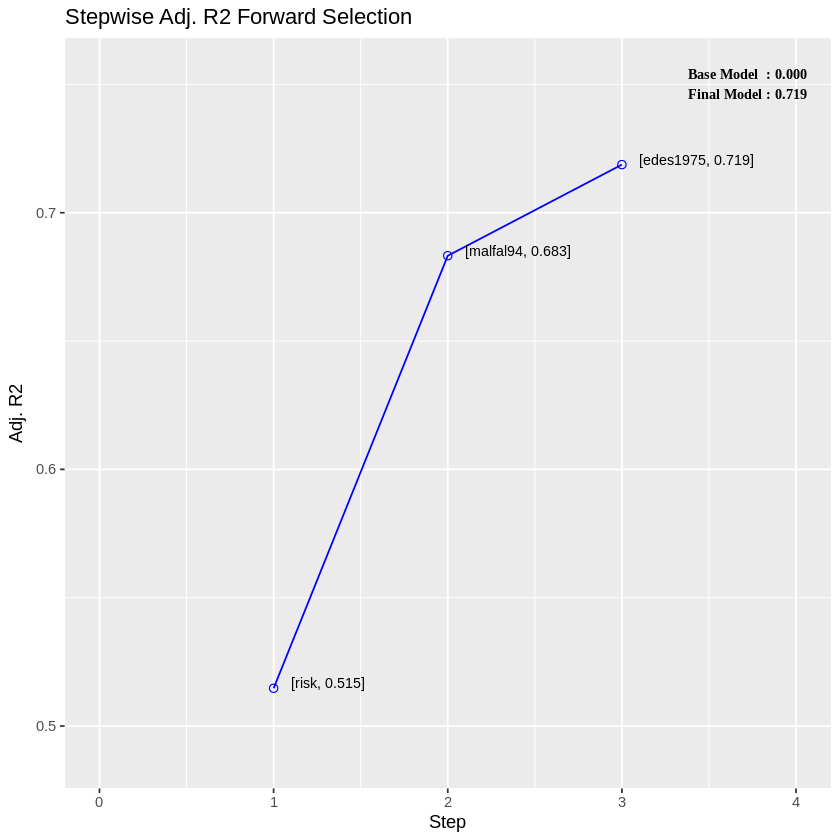

In [24]:
k <- ols_step_forward_adj_r2(model.step, progress = TRUE)
plot(k)

In [25]:
ctrl <- trainControl(method = "cv", number = 5)

cv.caret.model <- train(loggdp ~ risk + slave + latitude + neoeuro + asia + africa + other + edes1975 + malfal94,
                        data = Data,
                        method = "lm",
                        trControl = ctrl)

print(cv.caret.model)

cv.caret.model$finalModel

Linear Regression 

62 samples
 9 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 50, 48, 50, 50, 50 
Resampling results:

  RMSE       Rsquared   MAE     
  0.6153312  0.6511205  0.465085

Tuning parameter 'intercept' was held constant at a value of TRUE



Call:
lm(formula = .outcome ~ ., data = dat)

Coefficients:
(Intercept)         risk        slave     latitude      neoeuro         asia  
   6.503155     0.294927    -0.206090    -0.580249     0.299710    -0.215260  
     africa        other     edes1975     malfal94  
  -0.110996    -0.306931     0.007804    -0.897310  


Los métodos automaticos seleccionan modelos relativamente pequeños. El mejor subset muestra que risk solo es el mejor modelo de una variable mientras risk + malfal94 es el mejor de dos variables, risk + malfal94 + edes1975 es el mejor de 3 variables. Por lo que risk, malfal94 y edes1975 son las variables que mas aportan información al modelo.

Por otro lado, los resultados de validación cruzada de 5 grupos para el modelo completo muestran un ajuste predictivo razonable pero no implica necesariamente que convenga quedarse con el modelo más grande por temas de interpretación.

###**j.**
 Which model from d,e,h,i and j would you select? and why?

El modelo seleccionado sería es risk + malfal94, porque es simple, tiene buen desempeño y mantiene el efecto de risk significativo. Por otro lado, en una muestra pequeña es mejor evitar modelos demasiado grandes.

###**k.**
How does your selection compares to the IV specificaiton used by the authors?

In [26]:
Data.iv <- subset(Data, complete.cases(Data[, c("loggdp", "risk", "logmort0", "latitude", "africa", "asia", "other")]))

iv.model <- ivreg(loggdp ~ risk + latitude + africa + asia + other |
                    logmort0 + latitude + africa + asia + other,
                  data = Data.iv)

summary(iv.model, diagnostics = TRUE)


Call:
ivreg(formula = loggdp ~ risk + latitude + africa + asia + other | 
    logmort0 + latitude + africa + asia + other, data = Data.iv)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7747 -0.6373 -0.1265  0.8237  2.1209 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   1.2803     2.9597   0.433   0.6670  
risk          1.1319     0.4849   2.334   0.0232 *
latitude     -1.1781     1.8200  -0.647   0.5201  
africa       -0.4223     0.4344  -0.972   0.3352  
asia         -1.1492     0.5524  -2.080   0.0421 *
other        -1.7863     1.4252  -1.253   0.2153  

Diagnostic tests:
                 df1 df2 statistic p-value   
Weak instruments   1  56     3.384  0.0711 . 
Wu-Hausman         1  55     9.577  0.0031 **
Sargan             0  NA        NA      NA   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.114 on 56 degrees of freedom
Multiple R-Squared: -0.06014,	Adjusted R-squared: -0.1548 
Wald tes

El modelo seleccionado es un modelo OLS, por lo que muestra una relación condicional entre instituciones e ingreso. En cambio, AJR usan una estrategia de variables instrumentales, donde logmort0 funciona como instrumento para risk, junto con controles geográficos como latitude, africa, asia y other. Por eso, la lógica del paper busca acercarse más a un efecto causal que a una simple asociación.

En la estimación IV, el coeficiente de risk sigue siendo positivo y significativo, y además su magnitud es mayor que en OLS. Esto sugiere que la endogeneidad sí importa y que el modelo OLS podría estar subestimando el efecto de las instituciones sobre el desempeño económico. De todas formas, los diagnósticos del instrumento también sugieren que estos resultados deben interpretarse con cierta cautela.